<a href="https://colab.research.google.com/github/tintin75011/Pythorch-course/blob/main/01_PyTorch_Workflow_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. PyTorch Workflow Fundamentals

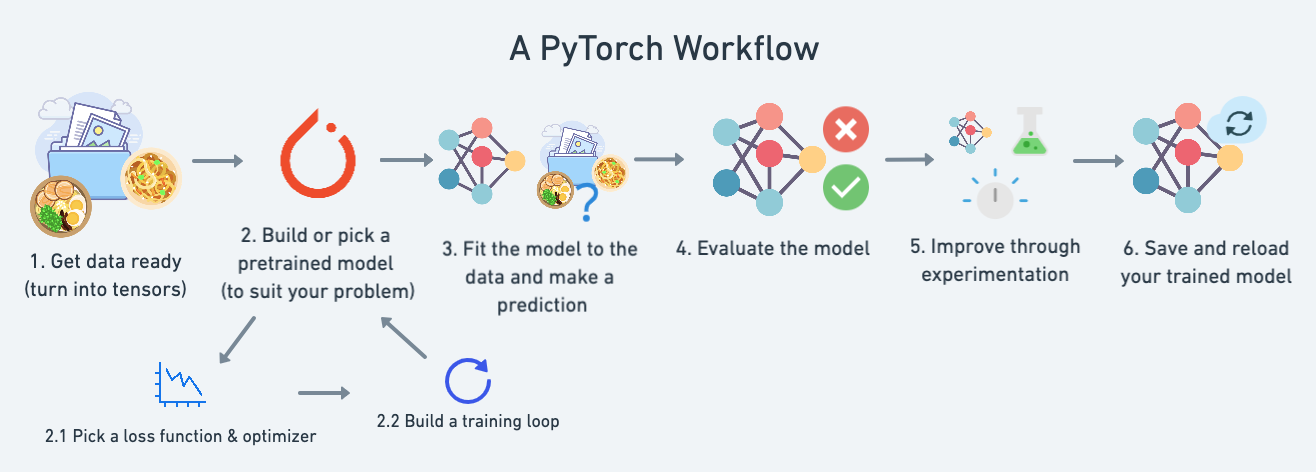

In [1]:
what_were_covering = {1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together"
}

In [2]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cpu'

Generating some Data

In [3]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

print(f"number of data : {len(X)}\n")
X[:10], y[:10]


number of data : 50



(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

Split data into training and test sets

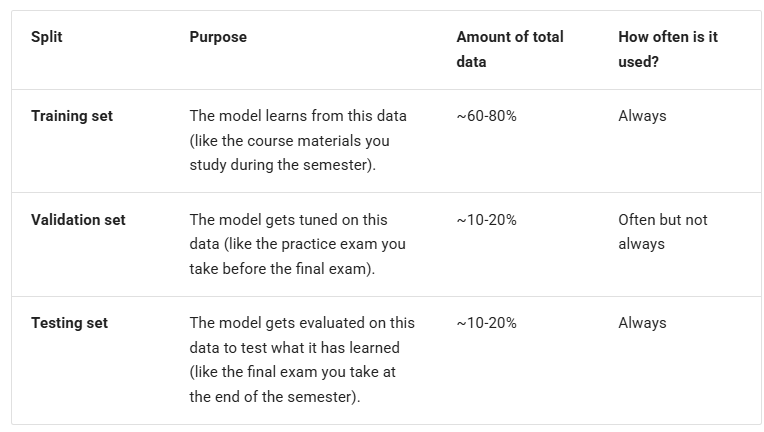

In [4]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split],y[:train_split]
X_test, y_test = X[train_split:],y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

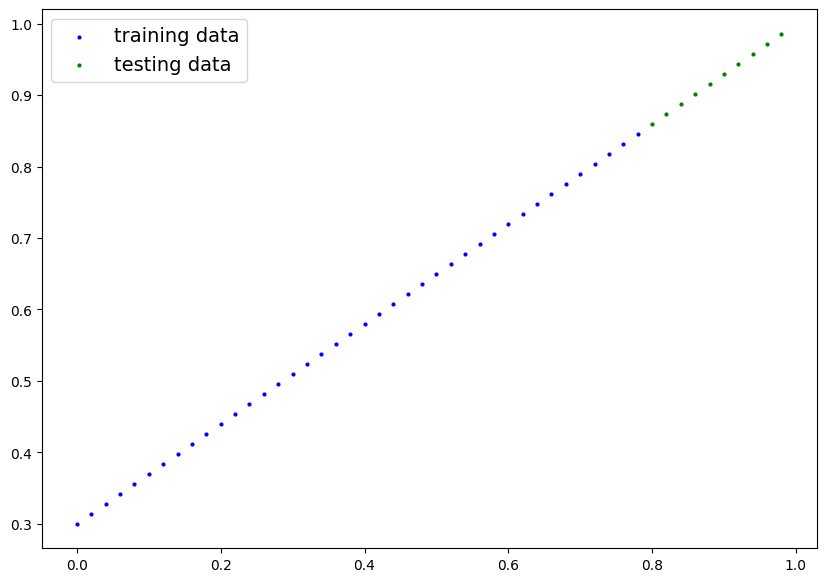

In [5]:
# definition of a function to visualize the data drom
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

  plt.figure(figsize=(10,7))

  #plot the training data as blue dot
  plt.scatter(train_data, train_labels, s = 4, c = "b", label = "training data")

  #plot the testing data as green dot
  plt.scatter(test_data, test_labels, s = 4, c = "g", label = "testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size":14})

plot_predictions();

Build the Model

In [6]:
# creation of a linear regression model class

class LinearRegressionModel(nn.Module):
  def __init__(self):#constructor of the class
    super().__init__() # call the constructor of the parent class nn.Module
    self.weights = nn.Parameter(torch.randn(1, dtype = torch.float)) #we give random weight that we are going to tune later

    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float)) #we give random bias that we are going to tune later

  # Forward defines the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor :# <- "x" is the input data (e.g. training/testing features)
    return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)



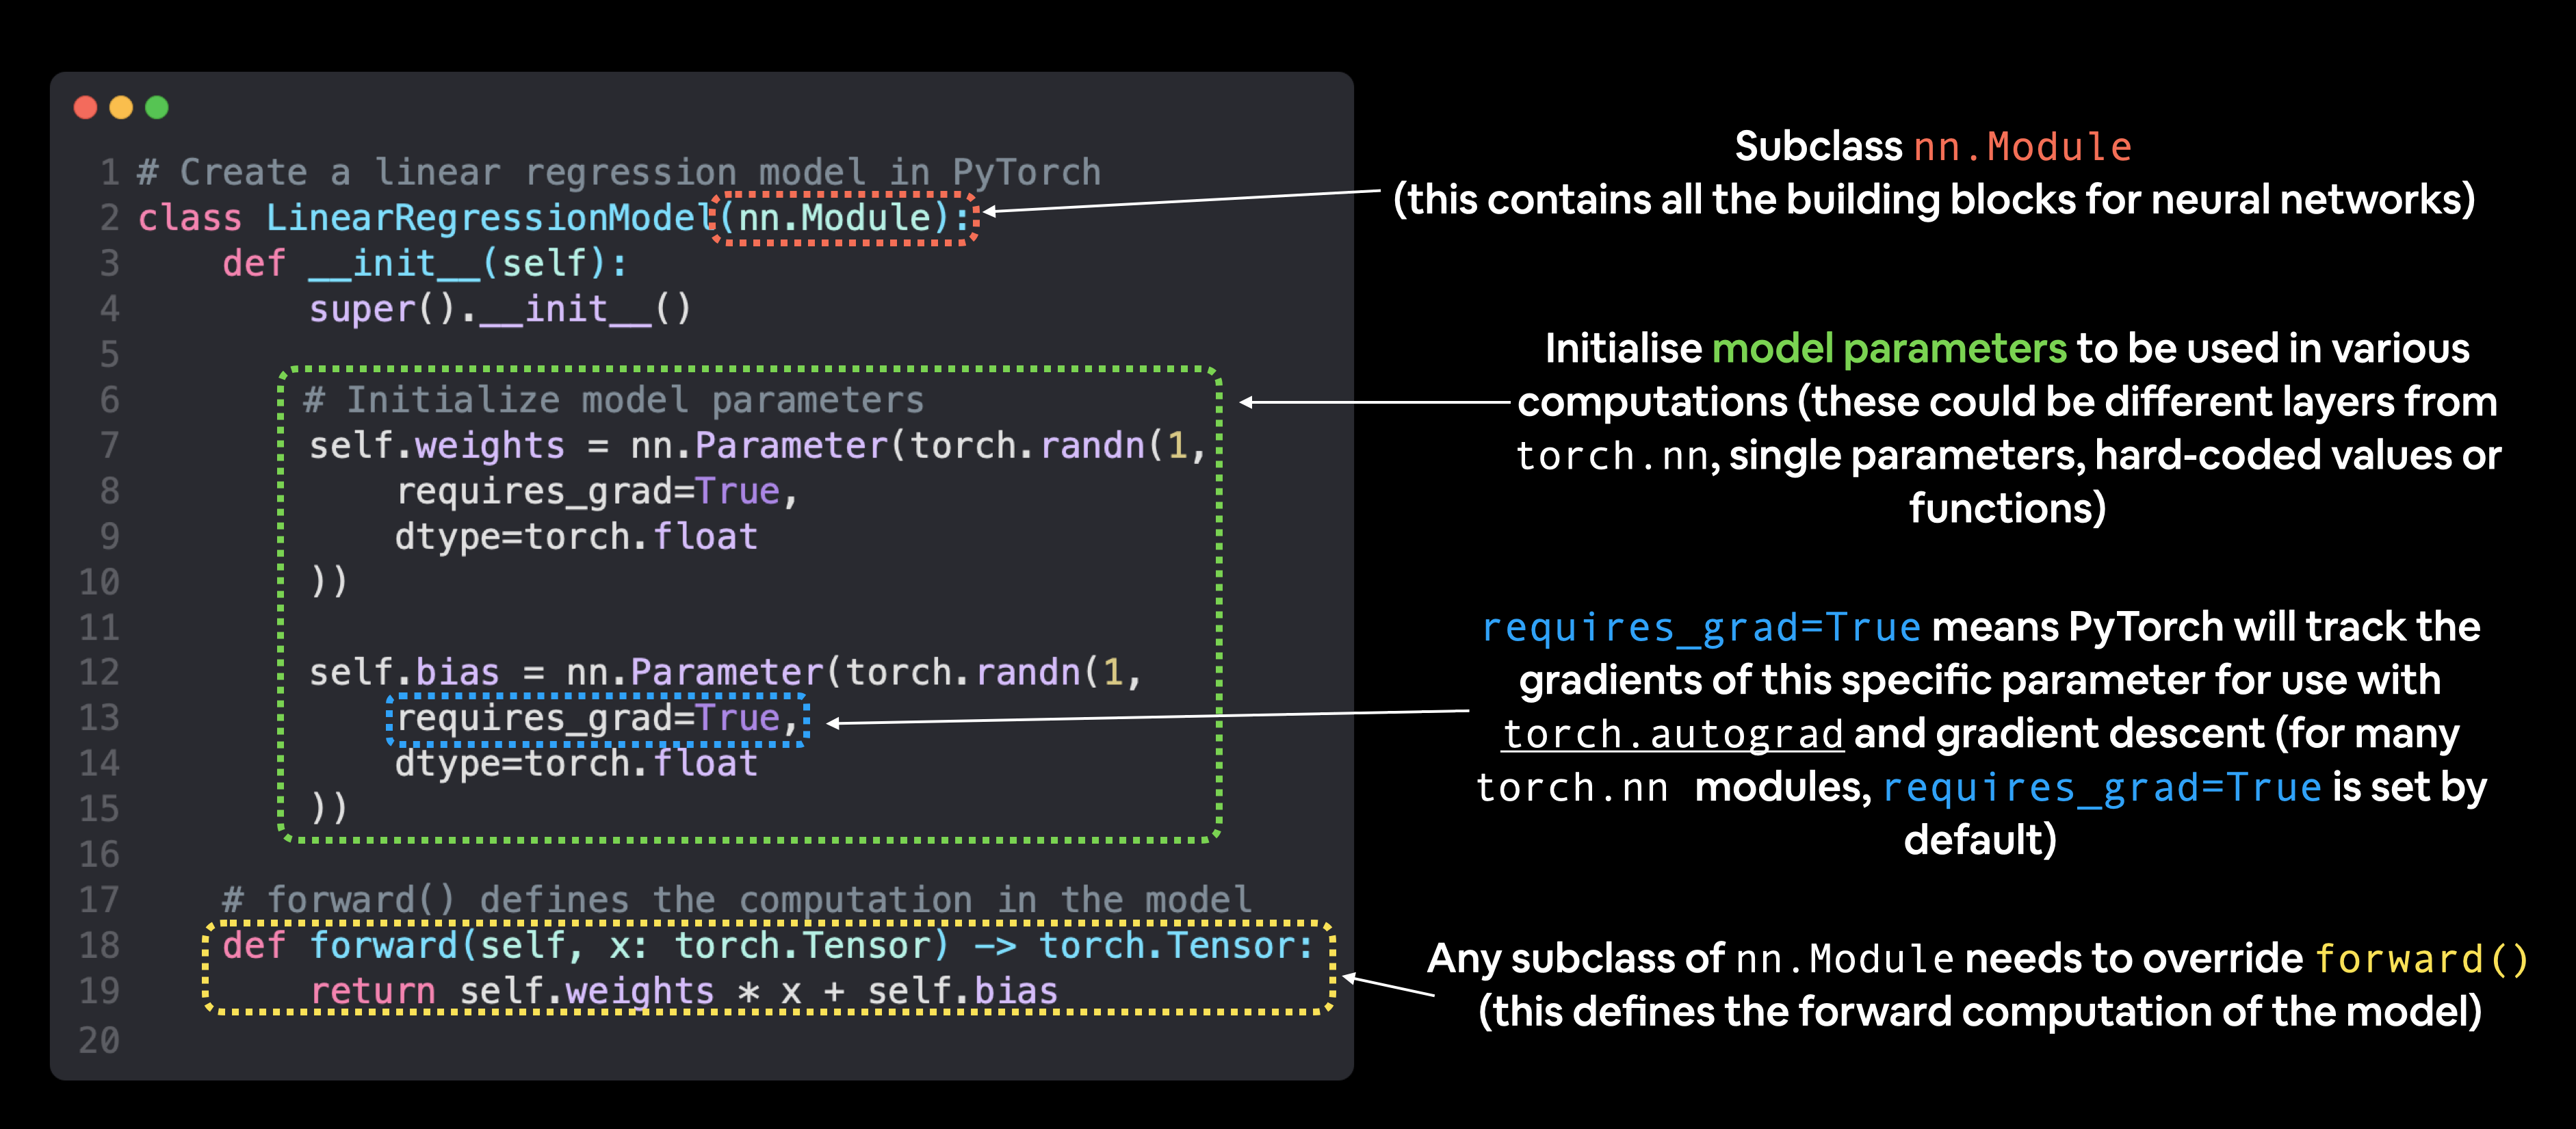

Checking the contents of a PyTorch model

In [7]:
torch.manual_seed(42) # as the parameter of the model are randomly initialized we set a manual seed as seen in part 00 of this tuto

model_0 = LinearRegressionModel() #we create an instance of the model wich is a subclass of nn.Moldel that contains nn.Parameters

list(model_0.parameters())
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


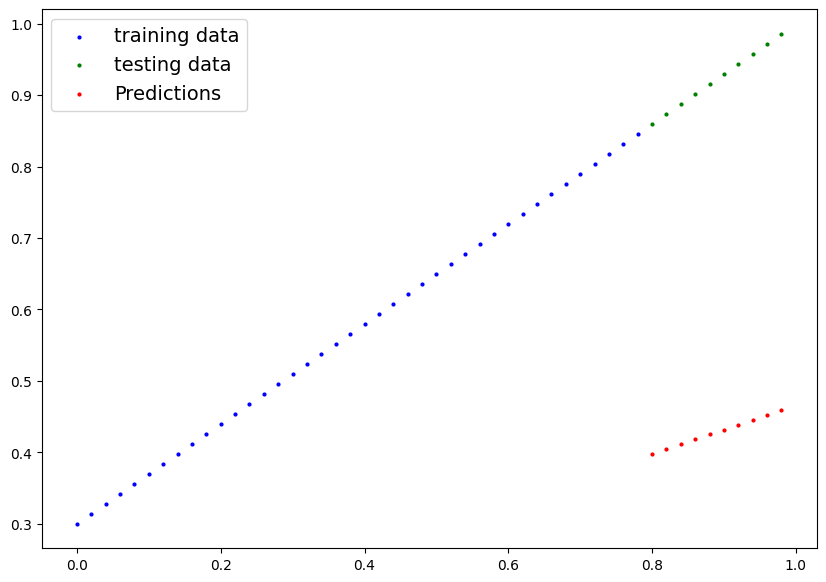

In [8]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

    # Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

plot_predictions(predictions=y_preds)

In [9]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])


**Train Model**

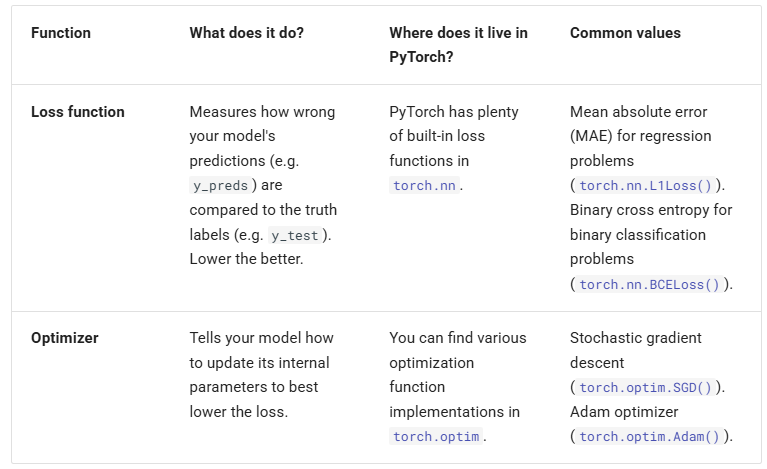

In [12]:
#create a loss function :
loss_fn = nn.L1Loss()

#create an optimize :
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)


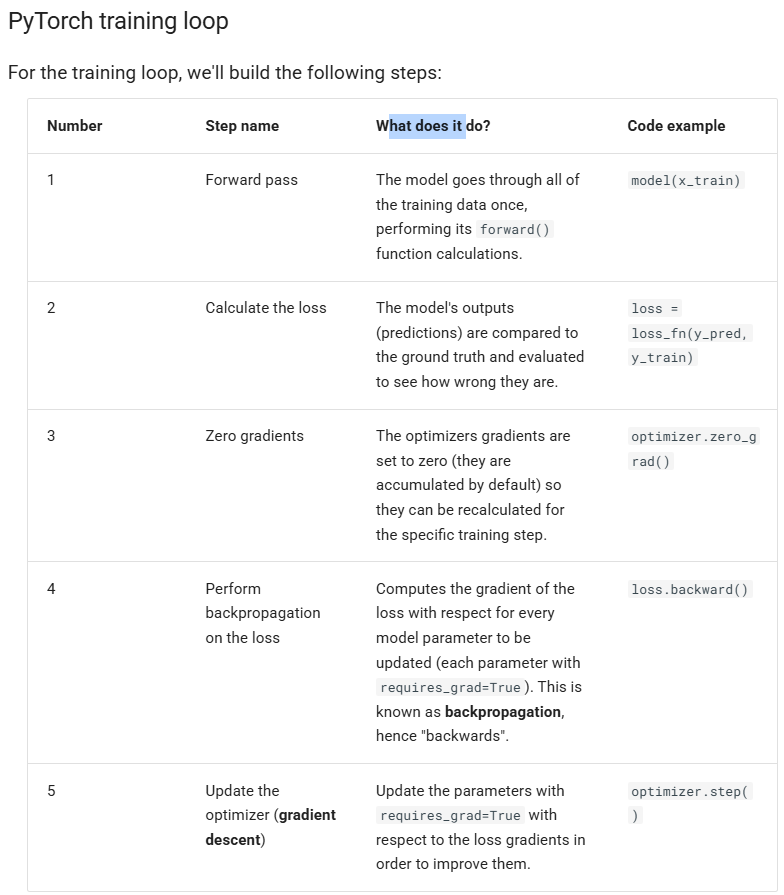

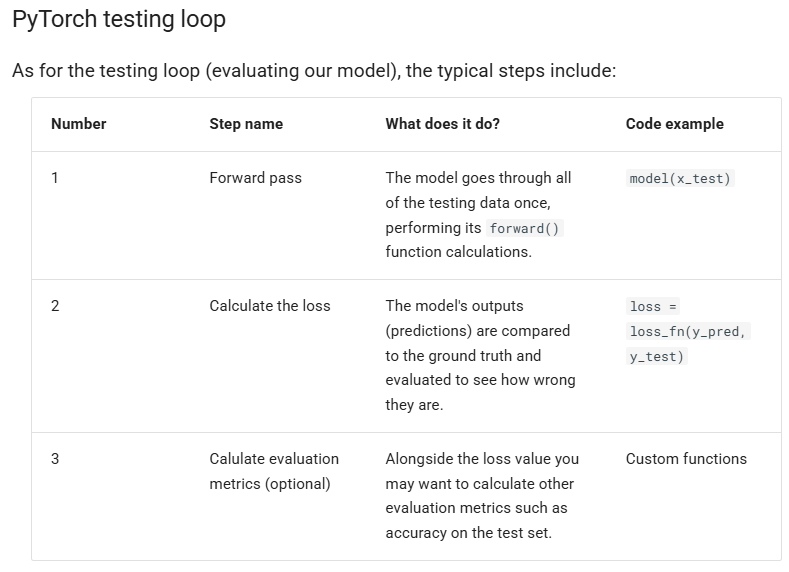

In [13]:
torch.manual_seed(42)

#set the number of epoch wich is how many times the model will pass over the training data
epochs = 100

#create empty loss list to track values
train_loss_values = []
test_loss_values = []
epoch_count = []


for epoch in range(epochs):
  #put model in training mode even thought this is the default mode of the model
  model_0.train()

  #1. Forward pass on training data using the forward() method we defined earlier
  y_pred = model_0(X_train)

  #2. calculate the loss wich represent how different the models prediction are from the actual values
  loss = loss_fn(y_pred, y_train)

  #3. reset the grad of the optimize wich is called the zero grad step
  optimizer.zero_grad()

  #4. Loss backward wich is also called gradient descent
  loss.backward()

  #5. Progress the optimizer
  optimizer.step()

  ### testing
  model_0.eval()

  with torch.inference_mode() :
    # 1. forward pass on test data
    test_pred = model_0(X_test)

    #2. calculate the loss on test data
    test_loss = loss_fn(test_pred, y_test)

    #print out what's happening
    if epoch % 10 == 0 :
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")


Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 


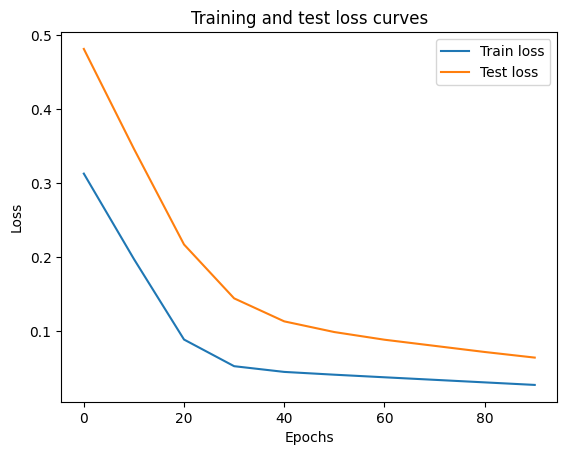

In [14]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [15]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.5784]), 'bias': tensor([0.3513])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3
